<div style="background: linear-gradient(90deg, #0b6623 0%, #2e8b57 50%, #98fb98 100%); padding: 20px; border-radius: 12px; text-align: center;">
  <h1 style="color: white; margin: 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, 'Helvetica Neue', Arial; font-weight: 700; font-size: 2.2rem;">
    Lab 2
  </h1>
</div>

# Import Library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# define Constant

In [3]:
lr=[1.0, 0.1, 0.01, 0.001, 0.0001]

epochs=1000

## Load Data

In [4]:
data2=np.array([[73,80,75,152],
[93,88,93,185],
[89,91,90,180],
[96,98,100,196],
[73,66,70,142],
[53,46,55,101],
[69,74,77,149],
[47,56,60,115],
[87,79,90,175],
[79,70,88,164],
[69,70,73,141],
[70,65,74,141],
[93,95,91,184],
[79,80,73,152],
[70,73,78,148],
[93,89,96,192],
[78,75,68,147],
[81,90,93,183],
[88,92,86,177],
[78,83,77,159],
[82,86,90,177],
[86,82,89,175],
[78,83,85,175],
[76,83,71,149],
[96,93,95,192]])

data2=pd.DataFrame(data2,columns=['Exam1','Exam2','Exam3','Score'])
print(data2.head())

   Exam1  Exam2  Exam3  Score
0     73     80     75    152
1     93     88     93    185
2     89     91     90    180
3     96     98    100    196
4     73     66     70    142


## Scaler Data

In [5]:
scaler=StandardScaler()
scaler_data=scaler.fit_transform(data2[['Exam1','Exam2','Exam3']])

## info from Data

In [6]:
print(data2.head())
print(f"{'-'*30}")
print(data2.shape)
print(f"{'-'*30}")
print(data2.describe())
print(f"{'-'*30}")
print(data2.info())

   Exam1  Exam2  Exam3  Score
0     73     80     75    152
1     93     88     93    185
2     89     91     90    180
3     96     98    100    196
4     73     66     70    142
------------------------------
(25, 4)
------------------------------
           Exam1      Exam2       Exam3       Score
count  25.000000  25.000000   25.000000   25.000000
mean   79.040000  79.480000   81.480000  162.040000
std    12.279658  12.503733   11.765486   24.044195
min    47.000000  46.000000   55.000000  101.000000
25%    73.000000  73.000000   73.000000  148.000000
50%    79.000000  82.000000   85.000000  164.000000
75%    88.000000  89.000000   90.000000  180.000000
max    96.000000  98.000000  100.000000  196.000000
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Exam1   25 non-null     int64
 1   Exam2   25 non-null     int64
 2   Exam

## Split data into Input and Target

In [7]:
X=data2[['Exam1','Exam2','Exam3']].values
y=data2['Score'].values

## prepare Data and define data with scaler and data without scaler

In [13]:
X_b2=np.c_[np.ones((X.shape[0],1)), X]
X_b_scaler=np.c_[np.ones((scaler_data.shape[0],1)),scaler_data]
theatas=np.zeros(X_b2.shape[1])

## Explore Data and find Correlation between Features

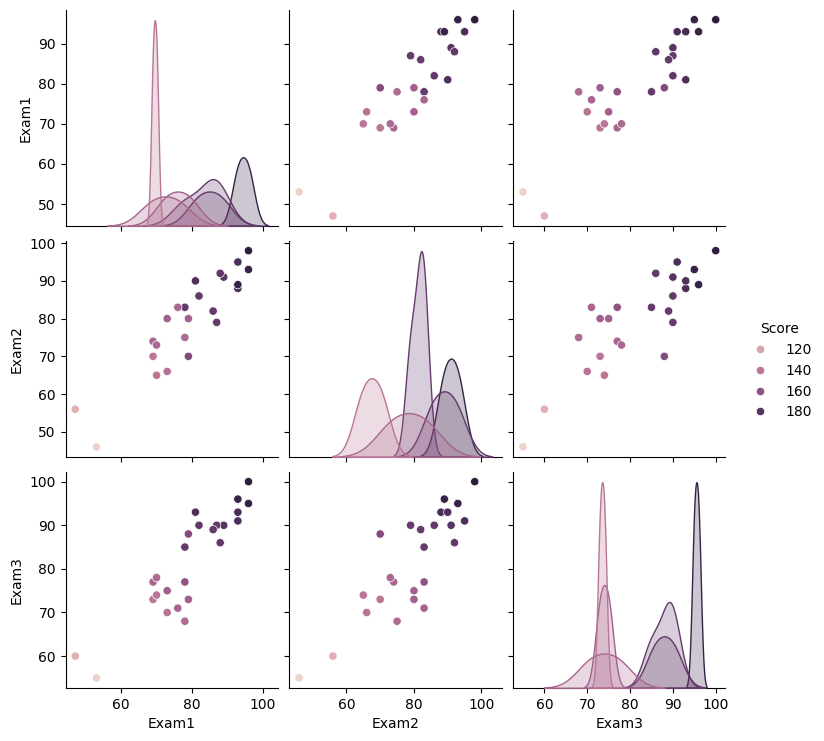

In [9]:
sns.pairplot(data2,hue='Score')
plt.show()

## Create Model

In [10]:
def model(X:np.array ,y:np.array,thetas:np.array, learning_rate, n_iterations:int):
    cost_history=[]
    grd=[]
    for i in range(n_iterations):
        h=X.dot(thetas)
        cost=np.sum((h-y) ** 2) / (2* len(y))
        if np.isnan(cost) or np.isinf(cost):
            print(f"Cost is NaN or Inf. Stopping training at iteration {i}.")
            break
        cost_history.append(cost)
        gradients=(1/len(y))*X.T.dot(h-y)
        gr=np.linalg.norm(gradients)
        grd.append(gr)
        thetas=thetas - learning_rate * gradients
    return thetas, cost_history, grd

## Plots

/tmp/ipython-input-448203714.py:6: RuntimeWarning: overflow encountered in square
  cost=np.sum((h-y) ** 2) / (2* len(y))
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Cost is NaN or Inf. Stopping training at iteration 36.
Cost is NaN or Inf. Stopping training at iteration 620.
Cost is NaN or Inf. Stopping training at iteration 46.
Cost is NaN or Inf. Stopping training at iteration 67.
Cost is NaN or Inf. Stopping training at iteration 120.


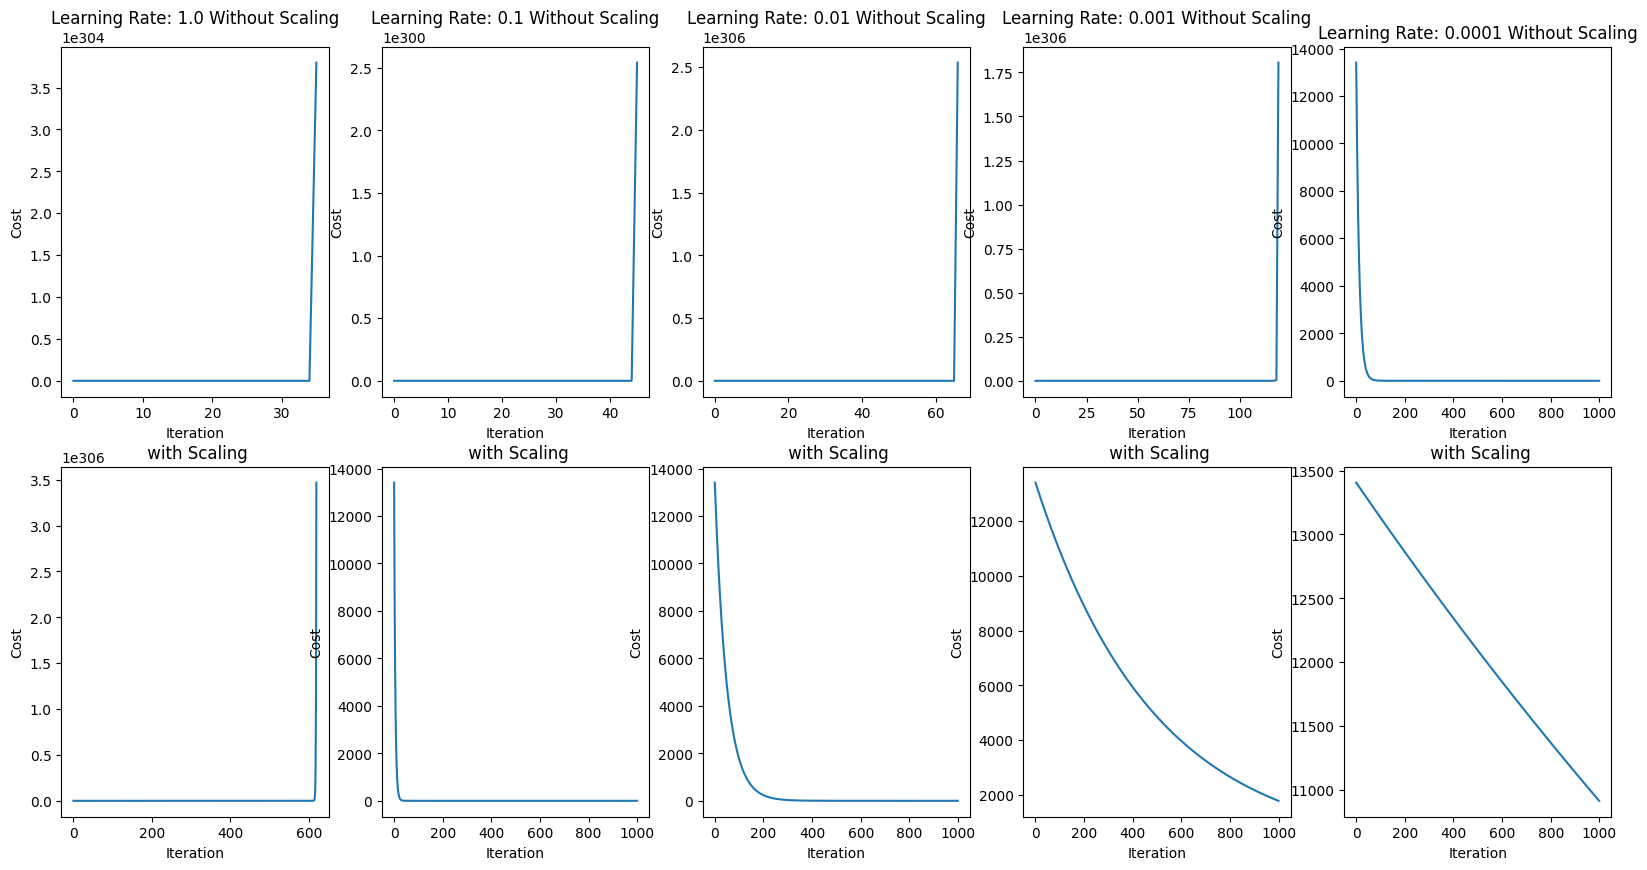

In [11]:
fig,ax=plt.subplots(nrows=2,ncols=5,figsize=(20,10))
for i in range(len(lr)):
    _ ,cost_lr ,_ =model(X_b2,y,theatas,lr[i],1000)
    ax[0,i].plot(cost_lr)
    ax[0,i].set_title(f"Learning Rate: {lr[i]} Without Scaling")
    ax[0,i].set_xlabel("Iteration")
    ax[0,i].set_ylabel("Cost")
    _ ,cost_lr2 ,_ =model(X_b_scaler,y,theatas,lr[i],1000)
    ax[1,i].plot(cost_lr2)
    ax[1,i].set_title(f" with Scaling")
    ax[1,i].set_xlabel("Iteration")
    ax[1,i].set_ylabel("Cost")
plt.show()


## Gradient Descent: Cost over Iterations

The plots illustrate the effect of **feature scaling** and **learning rate** on gradient descent.

---

### Unscaled Data (Top Row)
- Large learning rates (α = 1, 0.1, 0.01, 0.001) **cause divergence** due to large gradients.
- Very small learning rate (α = 0.0001) **converges slowly**.

---

### Scaled Data (Bottom Row)
- Standardization allows **higher learning rates safely**.
- α = 0.01 provides **stable and faster convergence**.
- Very large (α = 1) or very small learning rates converge **either too fast unstably or too slowly**.

---

### Takeaway
> Feature scaling is crucial for gradient descent, and **learning rate selection** significantly affects convergence speed and stability.


/tmp/ipython-input-448203714.py:6: RuntimeWarning: overflow encountered in square
  cost=np.sum((h-y) ** 2) / (2* len(y))


Cost is NaN or Inf. Stopping training at iteration 36.
Cost is NaN or Inf. Stopping training at iteration 620.
Cost is NaN or Inf. Stopping training at iteration 46.
Cost is NaN or Inf. Stopping training at iteration 67.
Cost is NaN or Inf. Stopping training at iteration 120.


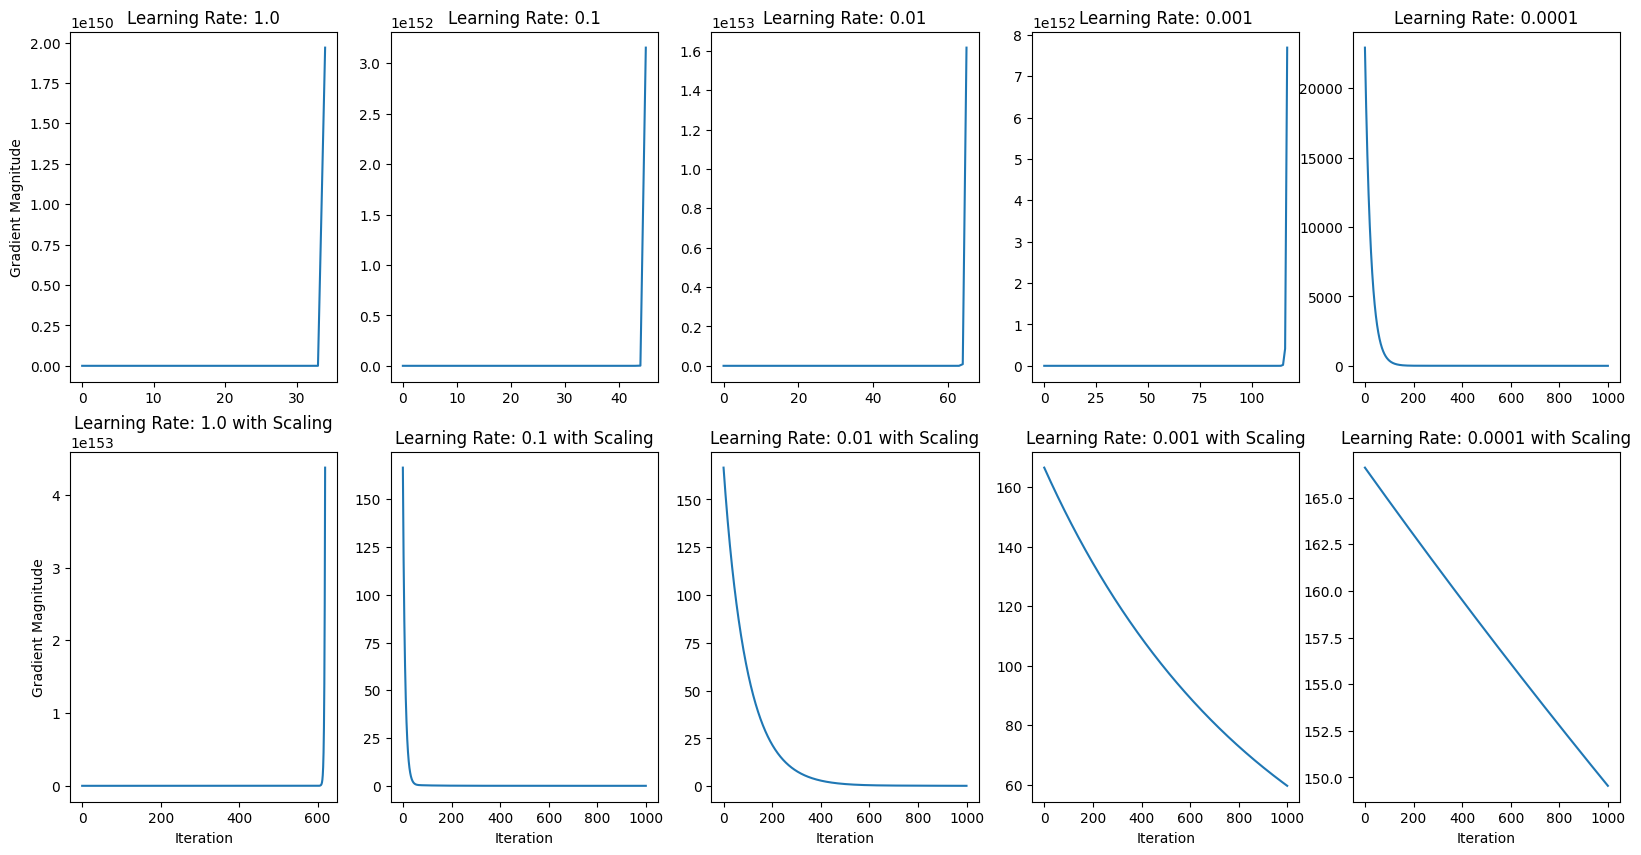

In [12]:
fig,ax=plt.subplots(nrows=2,ncols=5,figsize=(20,10))
for i in range(len(lr)):
    _ , _,gr1 =model(X_b2,y,theatas,lr[i],1000)
    ax[0,i].plot(gr1)
    ax[0,i].set_title(f"Learning Rate: {lr[i]}")
    ax[0,0].set_ylabel("Gradient Magnitude")

    _ ,_,gr2 =model(X_b_scaler,y,theatas,lr[i],1000)
    ax[1,i].plot(gr2)
    ax[1,i].set_title(f"Learning Rate: {lr[i]} with Scaling")
    ax[1,0].set_ylabel("Gradient Magnitude")
    ax[1,i].set_xlabel("Iteration")
    
plt.show()


## Gradient Descent: Effect of Learning Rate and Feature Scaling

The figure shows the **gradient magnitude over iterations** for different learning rates (α) with and without feature scaling.

---

###  Unscaled Data (Top Row)
- **Large learning rates** (α = 1, 0.1, 0.01, 0.001) lead to **divergence** due to large gradients.
- **Very small learning rate** (α = 0.0001) converges **very slowly**.

###  Scaled Data (Bottom Row)
- **Feature scaling** allows safe use of higher learning rates.
- α = 0.01 achieves **stable and fast convergence**.
- α = 1 diverges quickly, while α = 0.0001 converges **slowly but steadily**.

---

###  Key Takeaways
1. **Feature scaling is crucial** for gradient descent stability.
2. **Learning rate selection** greatly affects convergence speed and behavior.
3. Optimal learning rate after scaling gives **faster and more stable convergence**.
